In [1]:
from astropy import units as u
from astropy.constants import G, c, k_B, sigma_sb
import simple_disk as sd
from matplotlib import pyplot as plt
import disk_newton_solver as newton
import numpy as np
from disk_newton_solver import Tester
import pandas as pd
import seaborn as sns

In [2]:
M = 1e8 * u.Msun 


zone = 1
scale = "AGN"


ri = 6 * (G * M ) / (c**2)
rmax = 1000 * u.AU
n = 100
rstep = (rmax - ri)/n
rvals = []


rad = ri
while rad < rmax:
    #print(rad.to(u.AU))
    rvals.append(rad.to(u.AU))
    rad += rstep
max(rvals)
ri.to(u.AU)

simpleSols = []


for r in rvals:
    M = 1e8 * u.Msun 
    Mdot = 1e23 * u.kg/u.s 
    alpha = 0.1
    R_star = 6 * (G * M / c**2)
    fMdot = Mdot * (1.0 - np.sqrt((R_star / r).decompose()))
    scale = "AGN"

    for zone in [1,2,3]:
        rho = sd.rho(alpha, M, fMdot, r, zone, scale)
        Tc = sd.T_central(alpha, M, fMdot, r, zone, scale)
        Pressure = sd.pressure(alpha, M, fMdot, r, zone, scale)
        tau_star = sd.tau_star(alpha, M, fMdot, r, zone, scale)
        H = sd.h(alpha, M, fMdot, r, zone, scale)
        surface_flux = sd.Q(alpha, M, fMdot, r, zone, scale)
        nr = {}
        nr["R"] = r.to(u.AU).value
        nr["H"] = H.to(u.AU).value
        nr["zone"] = zone
        nr["rho"] = rho.cgs.value
        nr["Tc"] = Tc.to(u.K).value
        nr["P"] = Pressure.to(u.Pa).value
        nr["tau*"] = tau_star.si.value
        nr["SurfaceFlux"] = surface_flux.si.value
        nr["fMdot"] = fMdot.value
        nr["pratio"] = sd.pressure_ratio(alpha, M, fMdot, r, zone, scale).si.value
        nr["prad=pgas"] = 1 if np.abs(nr["pratio"] - 1) < 0.05 else 0
        
        
        simpleSols.append(nr)
simpledisk = pd.DataFrame(simpleSols)

newton_sols = []
for r in rvals:
    M = 1e8 * u.Msun 
    Mdot = 1e23 * u.kg/u.s 
    alpha = 0.1
    R_star = 2 * (G * M / c**2)
    
    solver = newton.AccretionDiskSolver(constants={"M_dot":Mdot, 'R':r, 'M':M, 'alpha':alpha*u.dimensionless_unscaled, 'R_star':R_star})
    
    if len(newton_sols) == 0:
        sdri = simpledisk[simpledisk["zone"]==1].sort_values("R")
        rho_init = sdri.loc[0,"rho"] * u.g / (u.cm**3)
        T_c_init = sdri.loc[0,"Tc"] * u.K

    rho, T_c, converged, iterations = solver.solve(
        rho_init, T_c_init,
    )
    nr = {}
    nr["R"] = r.to(u.AU).value
    nr["rho"] = rho.cgs.value
    nr["Tc"] = T_c.to(u.K).value
    nr["fMdot"] = fMdot.value
    newton_sols.append(nr)

newton_disk = pd.DataFrame(newton_sols)


In [3]:
simpledisk

,R,H,zone,rho,Tc,P,tau*,SurfaceFlux,fMdot,pratio,prad=pgas
0,5.922377,0.000000,1,inf,4.504794e+05,1.034229e+07,inf,0.000000e+00,0.000000e+00,inf,0
1,5.922377,0.000000,2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,inf,0
2,5.922377,0.000000,3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,inf,0
3,15.863153,4.134304,1,1.239078e-11,3.113257e+05,2.359264e+06,1.054848e-01,4.610644e+12,3.889830e+22,0.000023,0
4,15.863153,0.057249,2,4.675738e-06,2.641337e+06,1.706591e+08,8.881779e-07,4.610644e+12,3.889830e+22,0.013854,0
...,...,...,...,...,...,...,...,...,...,...,...
295,980.118448,5.166380,2,7.325774e-09,9.119980e+04,9.232152e+03,1.797322e-06,4.634685e+07,9.222664e+22,0.527295,0
296,980.118448,4.087896,3,4.976271e-09,5.692953e+04,3.898413e+03,2.197731e+03,4.634685e+07,9.222664e+22,1.472708,0
297,990.059224,9.806461,1,1.085891e-09,6.606753e+04,4.784858e+03,3.093700e+03,4.498385e+07,9.226576e+22,0.206845,0
298,990.059224,5.221856,2,7.206027e-09,9.039059e+04,9.000666e+03,1.800121e-06,4.498385e+07,9.226576e+22,0.532731,0


<Axes: xlabel='R', ylabel='H'>

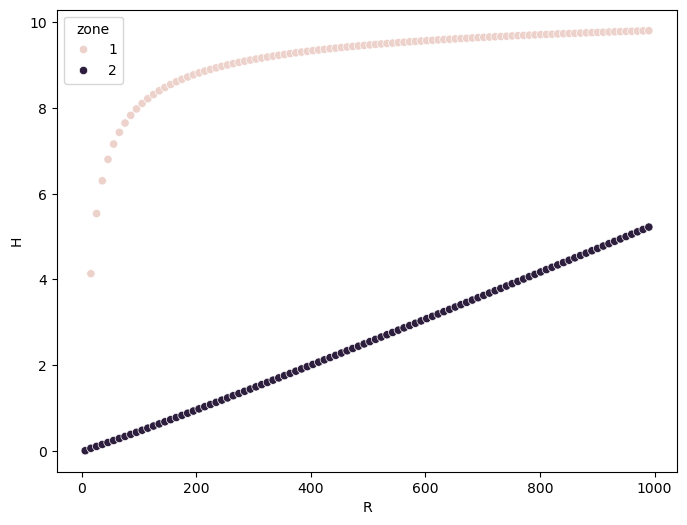

In [4]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(ax=ax, data=simpledisk[simpledisk["zone"] <= 2], x="R", y="H", hue="zone")


<Axes: xlabel='R', ylabel='Tc'>

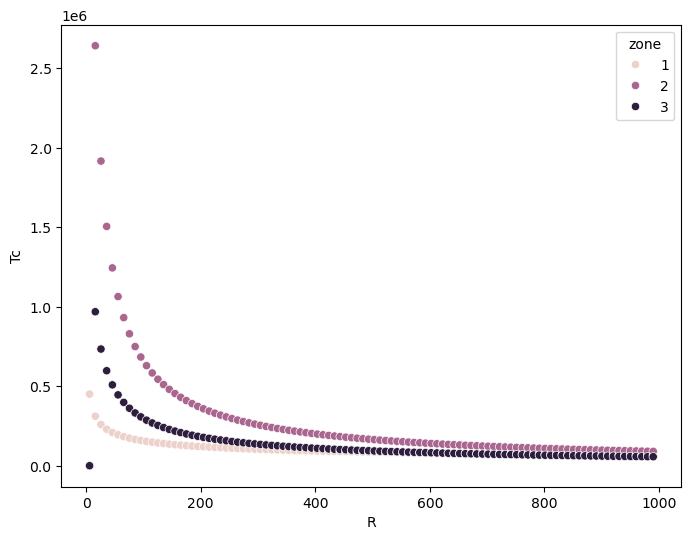

In [5]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(ax=ax, data=simpledisk, x="R", y="Tc", hue="zone")

<Axes: >

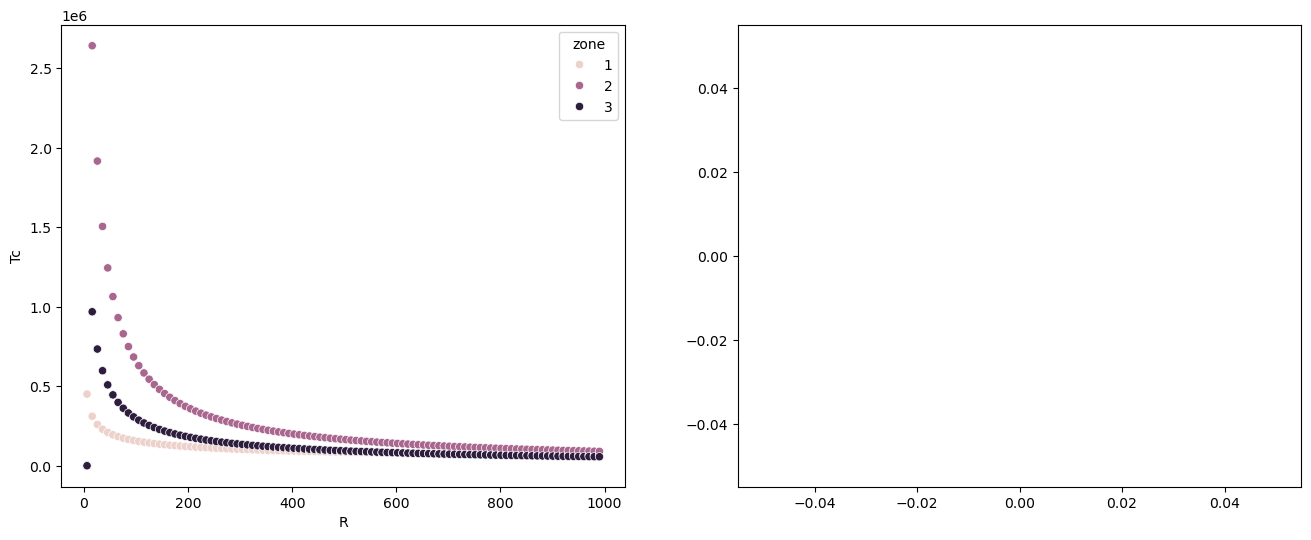

In [6]:
fig, ax = plt.subplots(1,2, figsize=(16,6))
ax = ax.flatten()
sns.scatterplot(ax=ax[0], data=simpledisk, x="R", y="Tc", hue="zone")
sns.scatterplot(ax=ax[1], data=newton_disk, x="R", y="Tc")

In [7]:
if False:#Test zone 1 (AGN scaling)
    M = 1e8 * u.Msun 
    Mdot = 1e23 * u.kg/u.s 
    r = 6 * (G * M / c**2)  
    alpha = 0.1
    R_star = 2 * (G * M / c**2)
    fMdot = Mdot * (1.0 - np.sqrt((R_star / r).decompose()))
    zone = 1
    scale = "AGN"
    #solution
    Sigma = sd.Sigma(alpha, M, fMdot, r, zone, scale)
    H = sd.h(alpha, M, fMdot, r, zone, scale)
    P = sd.pressure(alpha, M, fMdot, r, zone, scale)
    rho = sd.rho(alpha, M, fMdot, r, zone, scale)
    cs = np.sqrt((P/rho))
    Tc = sd.T_central(alpha, M, fMdot, r, zone, scale)
    tau = sd.tau_es(alpha, M, fMdot, r, zone, scale)
    visc = alpha * cs * H 

    Tester.check_solution(M=M, R=r, M_dot=Mdot, 
                        R_star=R_star, alpha=alpha, 
                        kappa_0=0.4*u.cm*u.cm/u.g, 
                        kappa_1=0* u.cm**5 / u.g**2 * u.K**(7/2), 
                        mu=0.6, Sigma=Sigma, 
                        H=H, c_s=cs, 
                        P=P, T_c=Tc, rho=rho,
                        tau=tau, nu=visc, 
                        tol=1e-3, verbose=True, show_values=True)